# PRÁCTICA: PREPROCESAMIENTO AVANZADO + RANDOM FOREST VS. XGBOOST

In [1]:
%pip install pandas seaborn scikit-learn xgboost matplotlib

Note: you may need to restart the kernel to use updated packages.


# 0. CARGAMOS LAS LIBRERIAS

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay

from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder

print("¡Librerias caragadas con éxito!")

¡Librerias caragadas con éxito!


# 1. CARGAR DATASET

**Dataset:** *Palmer Penguins* 🐧 - Perteneciente a la libreria "Seaborn"

In [3]:
df = sns.load_dataset('penguins')
print("Shape:", df.shape)
df.head()

Shape: (344, 7)


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


## EXPLORACIÓN INICIAL

### Nulos por Columna

* Aquí veremos qué variables (columnas) tienen datos nulos. 
* Si nuestra variable objetivo (`y`), en este caso `species`tuviera datos nulos, lo ideal sería quitar las filas correspondientes:

    ```python
    df = df.dropna(subset=['species']).reset_index(drop=True)
    ```


In [4]:
print("=========================")
print("=== NULOS POR COLUMNA ===")
print("=========================")
df.isnull().sum()

=== NULOS POR COLUMNA ===


species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64

### Descripción de las Variables numéricas

In [5]:
print("==============================================")
print("=== DESCRIPCIÓN DE LAS VARIABLES NUMÉRICAS ===")
print("==============================================")

df.describe()

=== DESCRIPCIÓN DE LAS VARIABLES NUMÉRICAS ===


,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
count,342.000000,342.000000,342.000000,342.000000
mean,43.921930,17.151170,200.915205,4201.754386
std,5.459584,1.974793,14.061714,801.954536
min,32.100000,13.100000,172.000000,2700.000000
25%,39.225000,15.600000,190.000000,3550.000000
50%,44.450000,17.300000,197.000000,4050.000000
75%,48.500000,18.700000,213.000000,4750.000000
max,59.600000,21.500000,231.000000,6300.000000


# 2. OUTLIERS

Detectamos outliers en `bill_length_mm` usando el método IQR y los visualizamos.


Outliers detectados en bill_length_mm: 0
Límites válidos: [25.31, 62.41]


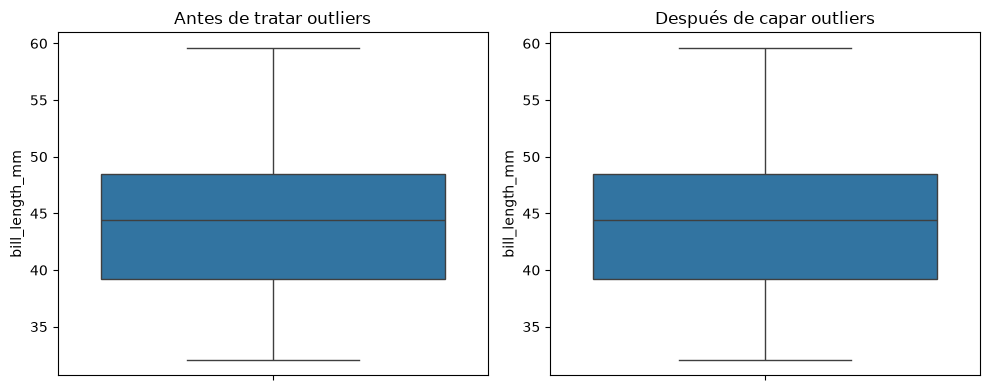

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
sns.boxplot(y=df['bill_length_mm'], ax=ax[0])
ax[0].set_title('Antes de tratar outliers')

Q1 = df['bill_length_mm'].quantile(0.25)
Q3 = df['bill_length_mm'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['bill_length_mm'] < lower_bound) | (df['bill_length_mm'] > upper_bound)]
print(f"Outliers detectados en bill_length_mm: {len(outliers)}")
print(f"Límites válidos: [{lower_bound:.2f}, {upper_bound:.2f}]")

# Tratamiento: "capping" (winsorizing) en vez de eliminar filas
df['bill_length_mm'] = df['bill_length_mm'].clip(lower_bound, upper_bound)

sns.boxplot(y=df['bill_length_mm'], ax=ax[1])
ax[1].set_title('Después de capar outliers')
plt.tight_layout()
plt.show()

💬 **Pregunta para el grupo:** ¿por qué hemos "capado" en vez de eliminar directamente las filas con outliers?

# 3. FEATURE ENGINEERING

Creamos una variable nueva: la relación entre longitud y profundidad del pico. 

Esta relación varía bastante entre especies, así que puede ayudar al modelo.


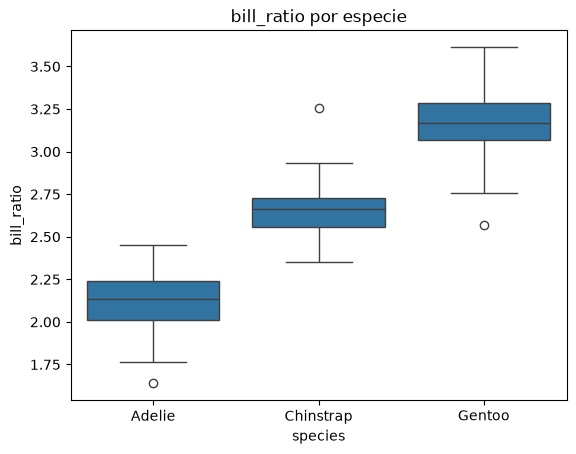

In [7]:
df['bill_ratio'] = df['bill_length_mm'] / df['bill_depth_mm']

sns.boxplot(data=df, x='species', y='bill_ratio')
plt.title('bill_ratio por especie')
plt.show()

# 4. ENCODING

`island` y `sex` son categóricas → las convertiremos con One-Hot Encoding, integrado dentro de un Pipeline de sklearn (esto evita tener que hacerlo a mano).


In [8]:
num_cols = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g', 'bill_ratio']
cat_cols = ['island', 'sex']

X = df[num_cols + cat_cols]
y = df['species']

# 5. TRAIN / TEST SPLIT

⚠️ Importante: dividimos ANTES de aplicar imputación/encoding para evitar data leakage (que información del test "se filtre" al train).

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Train:", X_train.shape, "Test:", X_test.shape)

Train: (275, 7) Test: (69, 7)


In [10]:
# Aplica transformaciones distintas a distintos grupos de columnas, de una vez.
preprocessor = ColumnTransformer([ # Columnas numericas
    ('num', SimpleImputer(strategy='median'), num_cols),  # Valores nulos rellenados con la mediana
    ('cat', Pipeline([ # Columnas categóricas
        ('imputer', SimpleImputer(strategy='most_frequent')),  # Valores nulos rellenados con más frecuentes
        ('onehot', OneHotEncoder(handle_unknown='ignore')) # Categorias divididas en columnas binarias / si aparece 
                                                    # una categoria "nueva" que no se había definido, codifica en 0
    ]), cat_cols)
])

# 6. MODELO 1: RANDOM FOREST

In [11]:
# Una vez transformados los datos:

rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(n_estimators=200, random_state=42)) # Usamos Random Forest con 200 árboles
])

rf_pipeline.fit(X_train, y_train) # Ajusta el preprocessor solo con X_train y entrena el RF junto con y_train

rf_preds = rf_pipeline.predict(X_test)

print("Random Forest - Accuracy:", accuracy_score(y_test, rf_preds)) # Compara las predicciones contra etiquetas
                                                                # de test y da el porcentaje de aciertos totales.
print(classification_report(y_test, rf_preds)) # Desglosa rendimiento por cada especie.

Random Forest - Accuracy: 1.0
              precision    recall  f1-score   support

      Adelie       1.00      1.00      1.00        30
   Chinstrap       1.00      1.00      1.00        14
      Gentoo       1.00      1.00      1.00        25

    accuracy                           1.00        69
   macro avg       1.00      1.00      1.00        69
weighted avg       1.00      1.00      1.00        69



* **PRECISION:** De las veces que el modelo dijo "Adelie", ¿cuántas acertó?
* **RECALL:** De todas las Adelie reales, ¿cuántas detectó el modelo?
* **F1-SCORE:** Combina precision y recall en un solo número.
* **SUPPORT:** Cuántos ejemplos reales de esa clase había en el test.

## VERIFICACIÓN ACCURACY = 1.0

Obtener una Accuracy de 1.0 puede resultarnos un poco sospechoso, por lo que convendría comprobarlo con el método `k-fold cross-validation` 

* Con cv=5 (5 folds), por ejemplo:
    * Entrena con el 80% y evalúa con el 20% → accuracy 1
    * Vuelve a entrenar con otro 80% distinto y evalúa con otro 20% → accuracy 2
    * ... y así 5 veces en total.

Al final tienes **5 accuracies distintos**, no uno solo. 

Si los 5 son consistentemente altos (ej: todos entre 0.95-1.0), el resultado es fiable. 

Si varían mucho (ej: 1.0, 0.85, 0.60...), es señal de que el random_state=42 de tu split original te tocó una combinación "fácil" por azar.

In [15]:
from sklearn.model_selection import cross_val_score

# Usamos el mismo rf_pipeline ya definido (preprocessor + modelo)
scores = cross_val_score(rf_pipeline, X, y, cv=5, scoring='accuracy')

print("Accuracy en cada fold:", scores)
print(f"Accuracy promedio: {scores.mean():.3f} (+/- {scores.std():.3f})")

Accuracy en cada fold: [1.         1.         1.         1.         0.95588235]
Accuracy promedio: 0.991 (+/- 0.018)


# 7. MODELO 2: XGBOOST

XGBoost necesita el target como números, no texto, así que usamos LabelEncoder solo para `y`.

In [12]:
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

xgb_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', XGBClassifier(
        n_estimators=200,
        max_depth=4,
        learning_rate=0.1,
        random_state=42,
        eval_metric='mlogloss'
    ))
])

xgb_pipeline.fit(X_train, y_train_enc)
xgb_preds = xgb_pipeline.predict(X_test)

print("XGBoost - Accuracy:", accuracy_score(y_test_enc, xgb_preds))
print(classification_report(y_test_enc, xgb_preds, target_names=le.classes_))


XGBoost - Accuracy: 1.0
              precision    recall  f1-score   support

      Adelie       1.00      1.00      1.00        30
   Chinstrap       1.00      1.00      1.00        14
      Gentoo       1.00      1.00      1.00        25

    accuracy                           1.00        69
   macro avg       1.00      1.00      1.00        69
weighted avg       1.00      1.00      1.00        69



## VERIFICACIÓN ACCURACY = 1.0


In [ ]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

# Codificamos 'y' completo para CV
y_enc_full = le.fit_transform(y)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(
    xgb_pipeline,
    X,
    y_enc_full,
    cv=cv,
    scoring='accuracy'
)

print("Cross‑Validation Accuracy por fold:", cv_scores)
print("Media:", cv_scores.mean())
print("Desviación estándar:", cv_scores.std())


Cross‑Validation Accuracy por fold: [1.         0.98550725 0.97101449 0.98550725 0.98529412]
Media: 0.985464620630861
Desviación estándar: 0.009166418649060697


# 8. COMPARATIVA E IMPORTANCIA DE VARIABLES

In [13]:
print(f"Random Forest Accuracy: {accuracy_score(y_test, rf_preds):.3f}")
print(f"XGBoost Accuracy:       {accuracy_score(y_test_enc, xgb_preds):.3f}")


Random Forest Accuracy: 1.000
XGBoost Accuracy:       1.000


## IMPORTANCIA DE VARIABLES SEGUN RANDOM FOREST

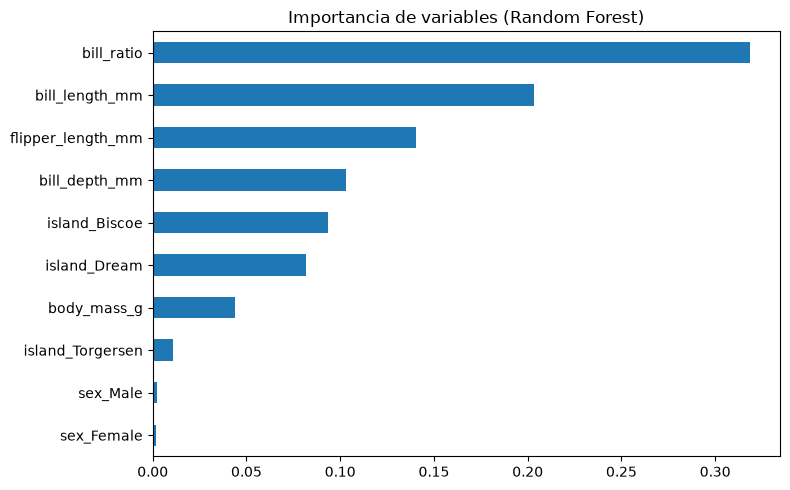

In [14]:
feature_names = (
    num_cols +
    list(rf_pipeline.named_steps['preprocessor']
        .named_transformers_['cat']
        .named_steps['onehot']
        .get_feature_names_out(cat_cols))
)
importances = rf_pipeline.named_steps['model'].feature_importances_

feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False)
feat_imp.plot(kind='barh', figsize=(8, 5), title='Importancia de variables (Random Forest)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# 💬 **Preguntas para el grupo:**
1. ¿Qué modelo dio mejor resultado? ¿Os sorprende?
2. Según el gráfico de importancia, ¿qué variable pesa más? ¿Tiene sentido biológicamente?
3. Si quitáramos `bill_ratio` (la variable que creamos), ¿creéis que bajaría el accuracy?
Probadlo cambiando `num_cols` y volviendo a ejecutar.
